# Market Sensitivity Analysis

In this notebook, we analyze how different portfolios behave relative to the equity market benchmark, represented by SPY.

The analysis focuses on:

- Beta vs SPY
- Rolling Beta
- Correlation vs SPY
- Tracking Error
- Information Ratio
- Upside Capture
- Downside Capture

The objective is to understand how sensitive each portfolio is to equity market movements and whether diversification reduces market exposure.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project folders
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
IMAGES_DIR = PROJECT_ROOT / "images"

OUTPUTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

# Load daily returns
returns = pd.read_csv(
    DATA_DIR / "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

# Load benchmark portfolio weights from notebook 09
benchmark_weights = pd.read_csv(
    OUTPUTS_DIR / "benchmark_portfolio_weights.csv",
    index_col=0
)

returns.head()

,GLD,QQQ,SPY,TLT
Date,,,,
2018-01-03,-0.002637,0.009717,0.006325,0.004782
2018-01-04,0.005127,0.001749,0.004215,-0.000159
2018-01-05,-0.001036,0.010043,0.006664,-0.002856
2018-01-08,-0.000160,0.003891,0.001829,-0.000637
2018-01-09,-0.004628,0.000062,0.002264,-0.013372


In [2]:
benchmark_weights

,GLD,QQQ,SPY,TLT
SPY Only,0.000000,0.000000,1.000000,0.000000
60/40 Portfolio,0.000000,0.000000,0.600000,0.400000
Equal Weight,0.250000,0.250000,0.250000,0.250000
Balanced,0.100000,0.300000,0.400000,0.200000
Risk Parity,0.269773,0.163727,0.212473,0.354027


In [3]:
# Reorder columns to match returns
benchmark_weights = benchmark_weights[returns.columns]

portfolio_returns = pd.DataFrame(index=returns.index)

for portfolio_name in benchmark_weights.index:
    weights = benchmark_weights.loc[portfolio_name]
    portfolio_returns[portfolio_name] = returns @ weights.values

portfolio_returns.head()

,SPY Only,60/40 Portfolio,Equal Weight,Balanced,Risk Parity
Date,,,,,
2018-01-03,0.006325,0.005708,0.004547,0.006138,0.003916
2018-01-04,0.004215,0.002466,0.002733,0.002692,0.002509
2018-01-05,0.006664,0.002856,0.003204,0.005004,0.001770
2018-01-08,0.001829,0.000842,0.001231,0.001755,0.000757
2018-01-09,0.002264,-0.003991,-0.003919,-0.002213,-0.005492


In [4]:
spy_returns = returns["SPY"]
trading_days = 252

market_sensitivity_results = {}

for portfolio_name in portfolio_returns.columns:
    port_ret = portfolio_returns[portfolio_name]

    covariance = np.cov(port_ret, spy_returns)[0, 1]
    spy_variance = np.var(spy_returns)

    beta = covariance / spy_variance
    correlation = port_ret.corr(spy_returns)

    active_return = port_ret - spy_returns
    tracking_error = active_return.std() * np.sqrt(trading_days)
    annualized_active_return = active_return.mean() * trading_days

    information_ratio = (
        annualized_active_return / tracking_error
        if tracking_error != 0
        else np.nan
    )

    market_sensitivity_results[portfolio_name] = {
        "Beta vs SPY": beta,
        "Correlation vs SPY": correlation,
        "Annualized Active Return": annualized_active_return,
        "Tracking Error": tracking_error,
        "Information Ratio": information_ratio
    }

market_sensitivity_summary = pd.DataFrame(market_sensitivity_results).T

market_sensitivity_summary.to_csv(
    OUTPUTS_DIR / "market_sensitivity_summary.csv"
)

market_sensitivity_summary

,Beta vs SPY,Correlation vs SPY,Annualized Active Return,Tracking Error,Information Ratio
SPY Only,1.000468,1.000000,0.000000,0.000000,NaN
60/40 Portfolio,0.555695,0.867001,-0.064334,0.104966,-0.612899
Equal Weight,0.539388,0.832878,-0.028380,0.111952,-0.253501
Balanced,0.738260,0.946520,-0.015960,0.069668,-0.229089
Risk Parity,0.391517,0.678491,-0.050260,0.142232,-0.353367


In [5]:
upside_downside_results = {}

up_market_days = spy_returns > 0
down_market_days = spy_returns < 0

for portfolio_name in portfolio_returns.columns:
    port_ret = portfolio_returns[portfolio_name]

    upside_capture = (
        port_ret[up_market_days].mean()
        / spy_returns[up_market_days].mean()
    )

    downside_capture = (
        port_ret[down_market_days].mean()
        / spy_returns[down_market_days].mean()
    )

    upside_downside_results[portfolio_name] = {
        "Upside Capture": upside_capture,
        "Downside Capture": downside_capture,
        "Capture Ratio": upside_capture / downside_capture
    }

capture_summary = pd.DataFrame(upside_downside_results).T

capture_summary.to_csv(
    OUTPUTS_DIR / "upside_downside_capture_summary.csv"
)

capture_summary

,Upside Capture,Downside Capture,Capture Ratio
SPY Only,1.000000,1.000000,1.000000
60/40 Portfolio,0.578178,0.575897,1.003961
Equal Weight,0.597065,0.558691,1.068686
Balanced,0.783640,0.763323,1.026617
Risk Parity,0.449692,0.410134,1.096452


Upside Capture > 1  → partecipa più di SPY ai rialzi
Upside Capture < 1  → partecipa meno di SPY ai rialzi

Downside Capture > 1 → perde più di SPY nei ribassi
Downside Capture < 1 → perde meno di SPY nei ribassi

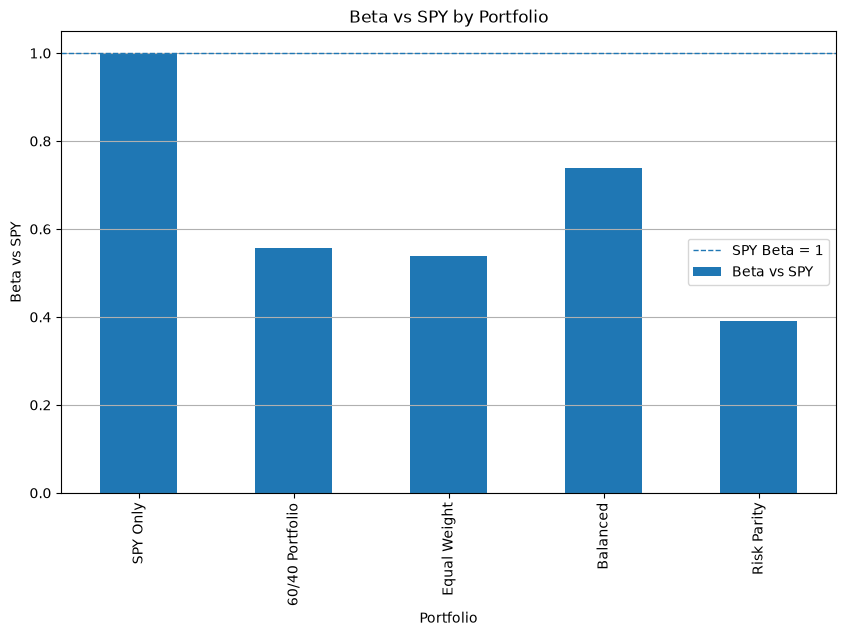

In [6]:
ax = market_sensitivity_summary["Beta vs SPY"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Beta vs SPY by Portfolio")
plt.xlabel("Portfolio")
plt.ylabel("Beta vs SPY")
plt.axhline(1, linestyle="--", linewidth=1, label="SPY Beta = 1")
plt.grid(axis="y")
plt.legend()

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "market_sensitivity_beta_vs_spy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

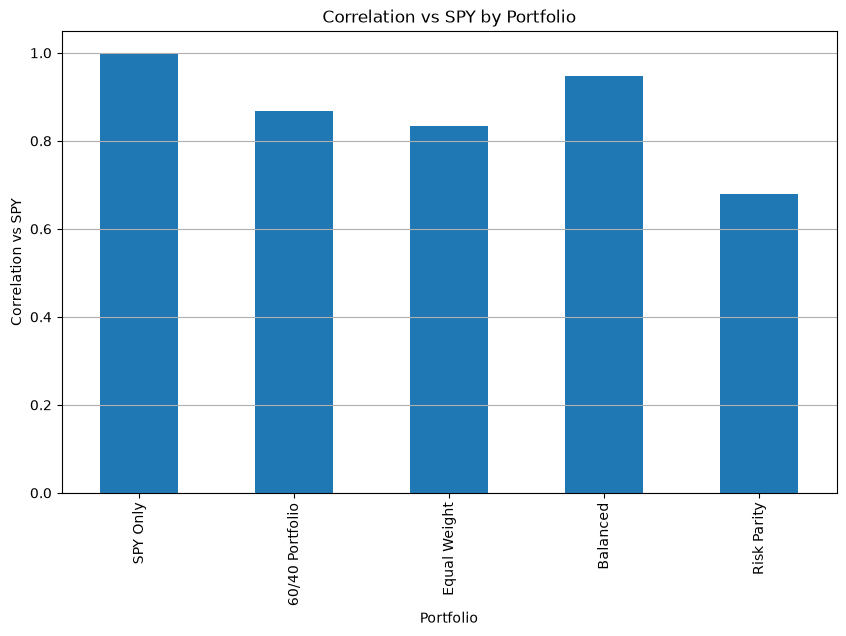

In [7]:
ax = market_sensitivity_summary["Correlation vs SPY"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Correlation vs SPY by Portfolio")
plt.xlabel("Portfolio")
plt.ylabel("Correlation vs SPY")
plt.grid(axis="y")

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "market_sensitivity_correlation_vs_spy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

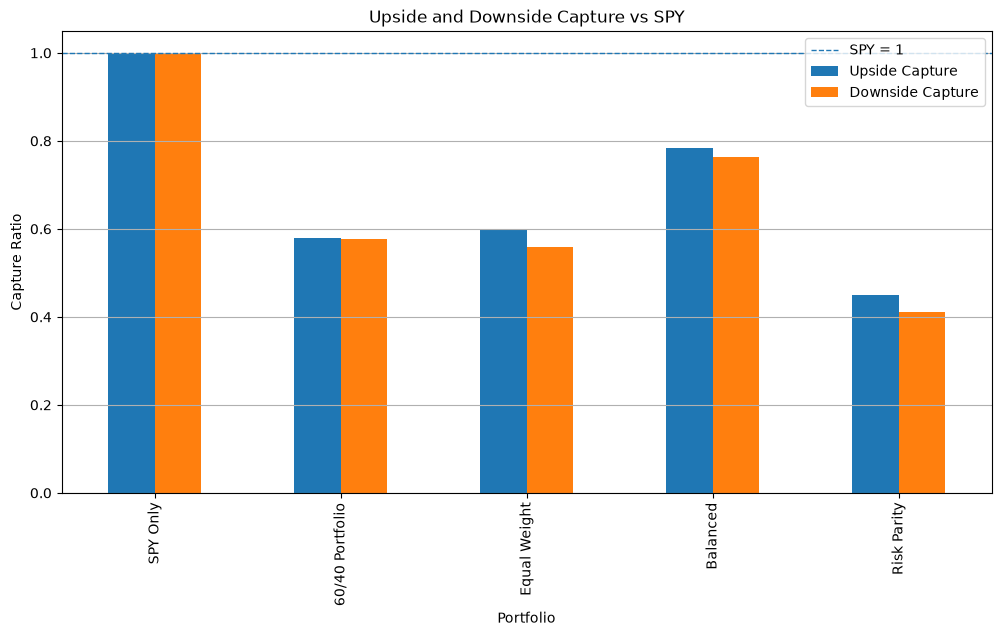

In [8]:
capture_plot = capture_summary[
    ["Upside Capture", "Downside Capture"]
]

ax = capture_plot.plot(kind="bar", figsize=(12, 6))

plt.title("Upside and Downside Capture vs SPY")
plt.xlabel("Portfolio")
plt.ylabel("Capture Ratio")
plt.axhline(1, linestyle="--", linewidth=1, label="SPY = 1")
plt.grid(axis="y")
plt.legend()

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "upside_downside_capture_vs_spy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
rolling_window = 126  # approximately 6 months

rolling_beta = pd.DataFrame(index=portfolio_returns.index)

for portfolio_name in portfolio_returns.columns:
    rolling_covariance = portfolio_returns[portfolio_name].rolling(
        rolling_window
    ).cov(spy_returns)

    rolling_variance = spy_returns.rolling(
        rolling_window
    ).var()

    rolling_beta[portfolio_name] = rolling_covariance / rolling_variance

rolling_beta.to_csv(
    OUTPUTS_DIR / "rolling_beta_vs_spy.csv"
)

rolling_beta.tail()

,SPY Only,60/40 Portfolio,Equal Weight,Balanced,Risk Parity
Date,,,,,
2026-06-30,1.0,0.687160,0.887013,0.957088,0.769502
2026-07-01,1.0,0.688507,0.883870,0.956725,0.766099
2026-07-02,1.0,0.688325,0.883504,0.957150,0.765338
2026-07-06,1.0,0.685497,0.883451,0.957047,0.764354
2026-07-07,1.0,0.687668,0.887495,0.960657,0.768406


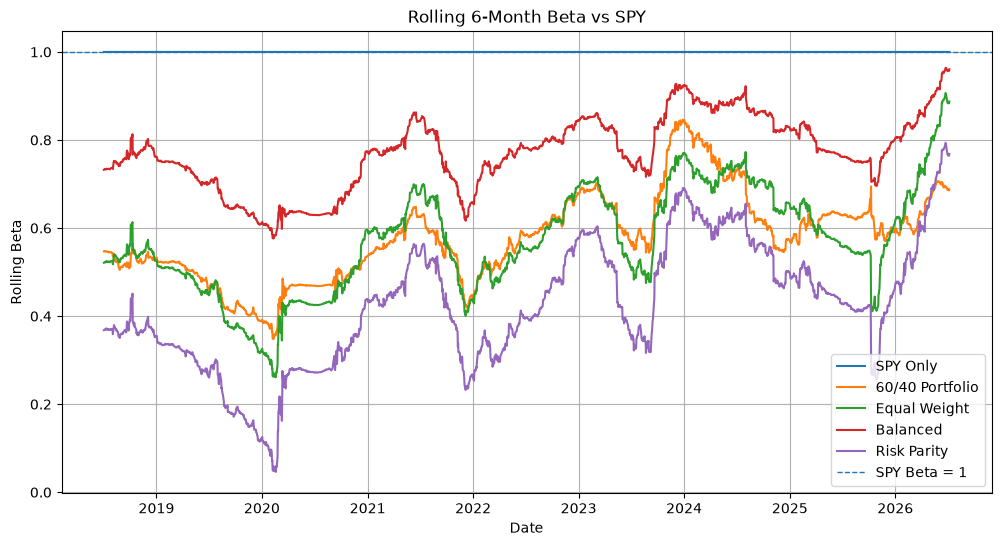

In [10]:
plt.figure(figsize=(12, 6))

for portfolio_name in rolling_beta.columns:
    plt.plot(
        rolling_beta.index,
        rolling_beta[portfolio_name],
        label=portfolio_name
    )

plt.title("Rolling 6-Month Beta vs SPY")
plt.xlabel("Date")
plt.ylabel("Rolling Beta")
plt.axhline(1, linestyle="--", linewidth=1, label="SPY Beta = 1")
plt.legend()
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "rolling_beta_vs_spy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
tracking_info = market_sensitivity_summary[
    ["Annualized Active Return", "Tracking Error", "Information Ratio"]
]

tracking_info.to_csv(
    OUTPUTS_DIR / "tracking_error_information_ratio.csv"
)

tracking_info

,Annualized Active Return,Tracking Error,Information Ratio
SPY Only,0.000000,0.000000,NaN
60/40 Portfolio,-0.064334,0.104966,-0.612899
Equal Weight,-0.028380,0.111952,-0.253501
Balanced,-0.015960,0.069668,-0.229089
Risk Parity,-0.050260,0.142232,-0.353367


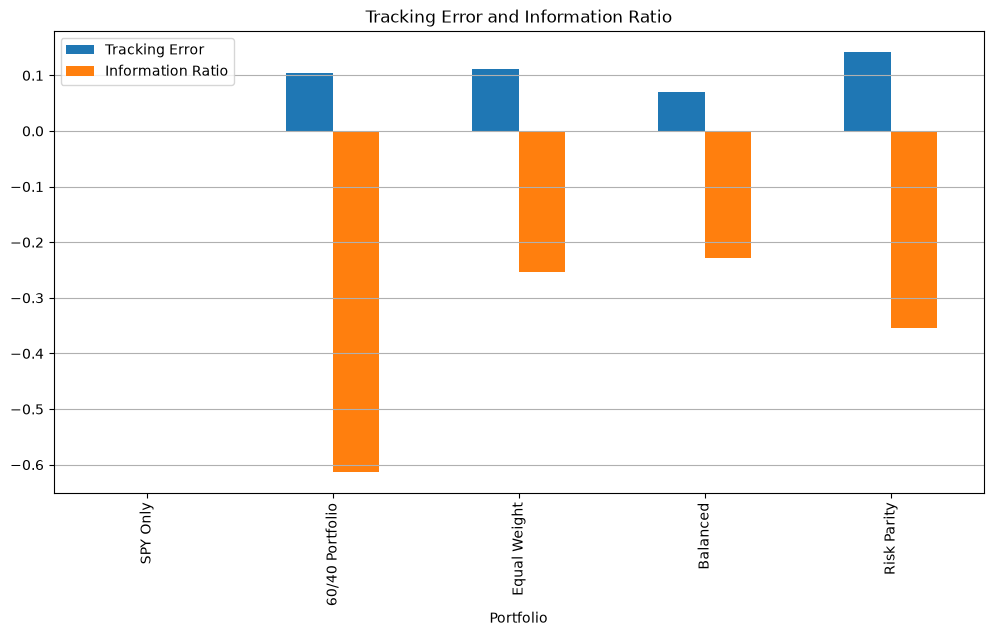

In [12]:
ax = tracking_info[["Tracking Error", "Information Ratio"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Tracking Error and Information Ratio")
plt.xlabel("Portfolio")
plt.grid(axis="y")

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "tracking_error_information_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Market Sensitivity Interpretation

This notebook analyzes how each portfolio behaves relative to SPY, which is used as the equity market benchmark.

### Beta vs SPY

Beta measures how sensitive each portfolio is to movements in SPY.

A beta close to 1 means that the portfolio tends to move similarly to SPY.  
A beta below 1 means that the portfolio is less sensitive to equity market movements.  
A beta above 1 means that the portfolio has greater sensitivity than SPY.

The SPY Only portfolio should naturally have a beta close to 1. Portfolios with more diversification across bonds and gold should generally show lower beta.

### Correlation vs SPY

Correlation measures how closely each portfolio moves with SPY.

A high correlation means that the portfolio behaves similarly to the equity market.  
A lower correlation may indicate stronger diversification benefits.

However, lower correlation does not automatically mean better performance. It only means that the portfolio behaves differently from SPY.

### Upside and Downside Capture

Upside Capture measures how much of SPY's positive performance the portfolio captures during positive market days.

Downside Capture measures how much of SPY's negative performance the portfolio experiences during negative market days.

A defensive portfolio may have lower upside capture but also lower downside capture.  
A growth-oriented portfolio may capture more upside, but it may also suffer more during market declines.

### Rolling Beta

Rolling beta shows that market sensitivity is not constant over time.

During periods of market stress, correlations and beta can change significantly. This means that diversification benefits may weaken or strengthen depending on market conditions.

### Tracking Error and Information Ratio

Tracking Error measures how differently a portfolio behaves compared to SPY.

A high tracking error means the portfolio deviates more from SPY.  
A low tracking error means the portfolio behaves more similarly to SPY.

Information Ratio compares active return to tracking error. It helps evaluate whether taking a different exposure from SPY was rewarded by better performance.

### Overall Conclusion

This notebook adds a benchmark-relative perspective to the project.

The previous notebooks focused on absolute risk, return, Monte Carlo simulations, stress testing, optimization, and rebalancing. This notebook adds the question:

"How does the portfolio behave compared to the equity market?"

This is important because a portfolio can look diversified in terms of asset weights, but still behave similarly to SPY if equity exposure dominates the risk.

Overall, market sensitivity analysis helps determine whether each portfolio is mainly a lower-risk version of SPY, a diversified alternative, or a strategy with meaningfully different market behavior.